In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [74]:
df=pd.read_csv("Social_Network_Ads.csv")

In [75]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [76]:
df.drop_duplicates(inplace=True)

In [77]:
df.drop(["User ID","Gender"],axis=1,inplace=True)

In [78]:
np.round(df.describe(),2)

,Age,EstimatedSalary,Purchased
count,400.00,400.00,400.00
mean,37.66,69742.50,0.36
std,10.48,34096.96,0.48
min,18.00,15000.00,0.00
25%,29.75,43000.00,0.00
50%,37.00,70000.00,0.00
75%,46.00,88000.00,1.00
max,60.00,150000.00,1.00


In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.2,random_state=42)

In [80]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(x_train)

scaler.fit(x_test)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [81]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [82]:
np.round(x_train.describe())

,Age,EstimatedSalary
count,320.0,320.0
mean,38.0,70281.0
std,10.0,34431.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [83]:
np.round(x_train_scaled.describe(),2)

,Age,EstimatedSalary
count,320.00,320.00
mean,0.47,0.41
std,0.24,0.28
min,0.00,-0.03
25%,0.29,0.19
50%,0.45,0.42
75%,0.64,0.55
max,1.00,1.05


Text(0, 0.5, 'EstimatedSalary')

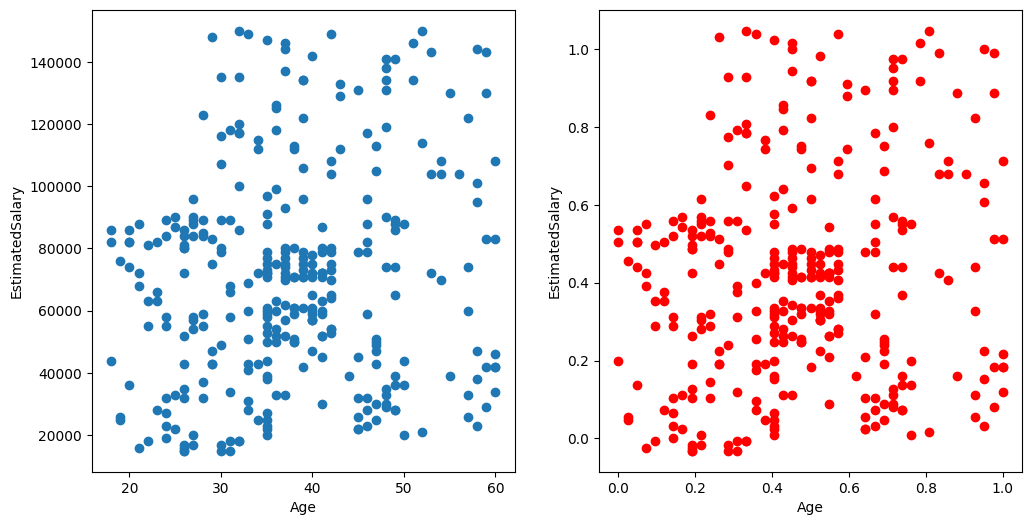

In [84]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,6))
ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="Red")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")


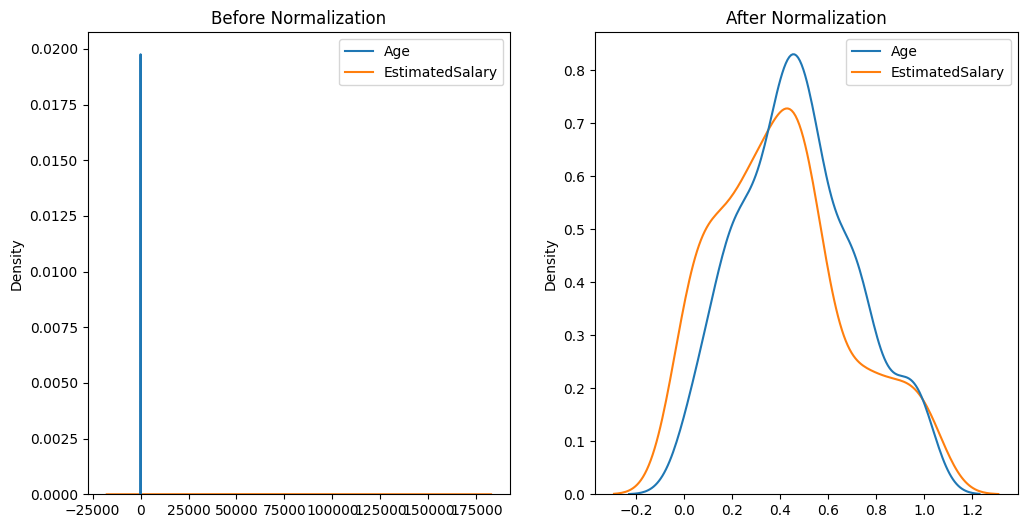

In [85]:
fig, (p1,p2)=plt.subplots(ncols=2, figsize=(12,6))

p1.set_title("Before Normalization")
p2.set_title("After Normalization")
sns.kdeplot(x_train,ax=p1, fill=False)
sns.kdeplot(x_train_scaled,ax=p2, fill=False)
plt.show()



In [86]:
df1=df.copy()

In [87]:
df1.loc[0, 'Age'] = 100
df1.loc[1, 'EstimatedSalary'] = 500000
df1.loc[2, 'EstimatedSalary'] = 600000

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

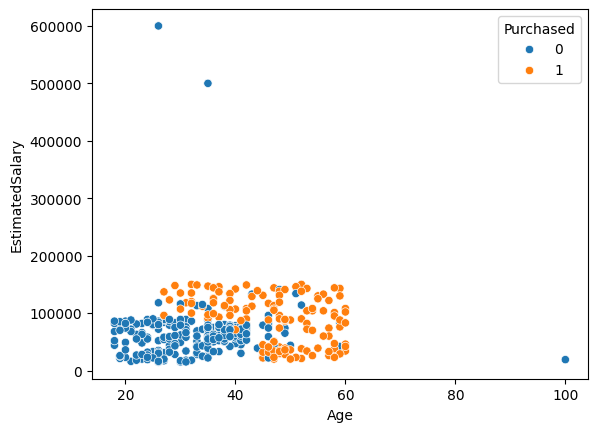

In [89]:
sns.scatterplot(data=df1, x="Age", y="EstimatedSalary", hue="Purchased")

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df1.drop("Purchased",axis=1),df1["Purchased"],test_size=0.2,random_state=42)

In [93]:
from sklearn.preprocessing import RobustScaler
robust_scaler=RobustScaler()
robust_scaler.fit(x_train)
robust_scaler.fit(x_test)
x_train_scaled=robust_scaler.transform(x_train)
x_test_scaled=robust_scaler.transform(x_test)

In [95]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

Text(0, 0.5, 'EstimatedSalary')

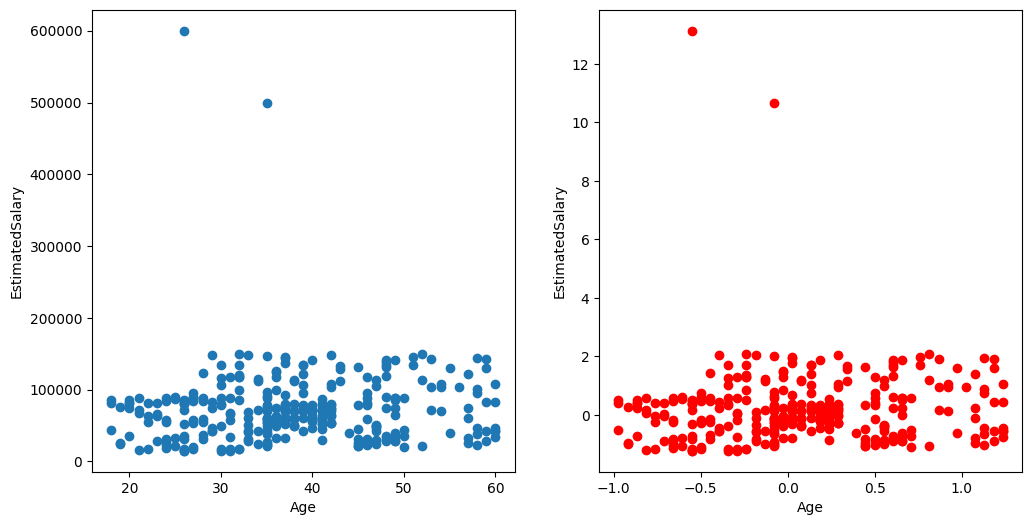

In [96]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,6))
ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="Red")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")


In [102]:
x_train.info

<bound method DataFrame.info of      Age  EstimatedSalary
3     27            57000
18    46            28000
202   39           134000
250   44            39000
274   57            26000
..   ...              ...
71    24            27000
106   26            35000
270   43           133000
348   39            77000
102   32            86000

[320 rows x 2 columns]>

In [103]:
x_train_scaled.info

<bound method DataFrame.info of           Age  EstimatedSalary
0   -0.500000        -0.196319
1    0.500000        -0.907975
2    0.131579         1.693252
3    0.394737        -0.638037
4    1.078947        -0.957055
..        ...              ...
315 -0.657895        -0.932515
316 -0.552632        -0.736196
317  0.342105         1.668712
318  0.131579         0.294479
319 -0.236842         0.515337

[320 rows x 2 columns]>